In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

2.10.0+cu128
cuda


In [3]:
train = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
test = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


In [4]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


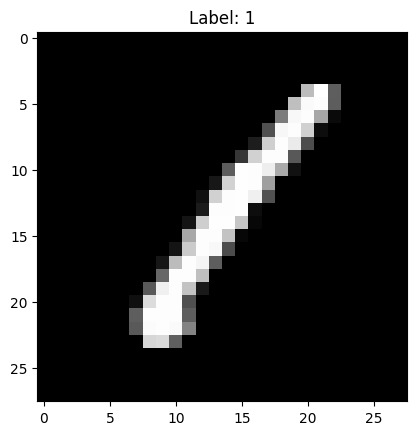

In [5]:
first_row = train.iloc[0,1:]
first_row_photo = first_row.values.reshape(28,28)

plt.imshow(first_row_photo,cmap="gray")
plt.title(f"Label: {train.iloc[0,0]}")
plt.show()

In [6]:
train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


*Let's normalize our data, cuz numbers like 255 makes it difficult to compute and slow down the learning of our model. So we squeeze them between 0-1. And how we gonna do that ? By dividing them by 255*


Now we need to prepare the data before feeding it into the model. We'll do this in two steps:1. Separate labels into pixels2. Normalize pixels (between 0 and 1)


In [7]:
labels = train.iloc[:, 0]
pixels = train.iloc[:, 1:]

print(labels.shape)
print(pixels.shape)

pixels = pixels / 255.0
pixels.max().max()

(42000,)
(42000, 784)


1.0

Normalization is done

Now let's move on to PyTorch. Pixels and labels are DataFrame/Series rn, but PyTorch wants tensors.

In [8]:
x = torch.tensor(pixels.values, dtype = torch.float32)
y = torch.tensor(labels.values, dtype = torch.long)

print(x.shape)
y.shape


# Why did we use `float32` for x, `long` for y?
# Cuz x values are pixels, they can be decimal numbers,
# y values are integers like 0,1,2...9 and `long` holds an integer value.
# PyTorch's `loss` function also expects labels to be `long`.

torch.Size([42000, 784])


torch.Size([42000])

***The question is: we have 42,000 images. When training the model, should we feed them all at once, or in batches?***

If you give it all at once, the model takes one step based on the average of 42,000 images. When you give it in chunks, it takes one step after each chunk — meaning it updates much more frequently and learns faster.
These chunks are called batches. Numbers like 32, 64, 128 are usually used.

In PyTorch, two classes do this:

* Dataset → holds the data, gives it when you say "give the i-th instance"

* DataLoader → takes the dataset, automatically divides it into batches, mixes them, and sends them to the GPU

First, we'll write the dataset. To write your own dataset in PyTorch, you create a class and need to write 3 methods:

* __init__ → get and store the data

* __len__ → how many instances are there?

* __getitem__ → give the i-th instance

In [9]:
from torch.utils.data import Dataset, DataLoader

In [10]:
class DigitDataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y


    def __len__(self):
        return len(self.x)

    def __getitem__(self,i):
        return self.x[i], self.y[i]

In [11]:
dataset = DigitDataset(x,y)
print(len(dataset))
print(dataset[0])

42000
(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0

In [12]:
dataloader = DataLoader(dataset,batch_size=64, shuffle=True)

one_batch = next(iter(dataloader))
print(one_batch[0].shape)
print(one_batch[1].shape)

torch.Size([64, 784])
torch.Size([64])



* [64, 784] → 64 images, each of them is 784 pixel
* [64] → labels of that 64 images



**Now, an important step: validation split.**

**What would happen if we used all 42,000 images in training? How would you know how well the model learned? What should we do?**


We're gonna split the train.csv into two parts:

* One part will be used to train the model → train
* The other part will be used to measure the model's performance → validation

The validation set is data the model has never seen before. It answers the question "Is the model really learning or is it memorizing?" during training. It's usually split 80% for training and 20% for validation.

PyTorch has a built-in function that does this: `random_split`.

In [13]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(len(train_dataset))
print(len(val_dataset))

33600
8400


80% of 42000 is 33600, 20% is 8400.

In [14]:
train_load = DataLoader(train_dataset,batch_size=64, shuffle=True)
val_load = DataLoader(val_dataset,batch_size=64, shuffle=False)

In [15]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = MLP()
print(model)

# The model is currently in the CPU — but our data will go to the GPU.
# The model in the CPU cannot work with the data in the GPU;
# they need to be in the same place.
model = MLP().to(device)
# Done!

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


Great! Now we need two more things for training:

1. Loss function → How wrong is the model's prediction?

   Our problem is classification — we're predicting one of 10 classes. The standard loss function for this is `CrossEntropyLoss`. Without going into too much detail, think of it this way: the model generates 10 numbers, and the correct answer is, let's say 3. `CrossEntropyLoss` looks at "how high is the score of 3, and how low are the others?" and generates an error number accordingly. If the error is high, the model is very wrong; if it's low, it's doing well.
3. Optimizer → How will we update the model based on the error?
   
    The optimizer does this: after the loss is calculated, it solves the question of "how much should I change which weights?".

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [17]:
for epoch in range(10):
    model.train()
    total_loss = 0
    
    for images, labels in train_load:
        images, labels = images.to(device), labels.to(device)
        
        pred = model(images)
        loss = loss_fn(pred, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    with torch.no_grad():
        count = 0
        for images, labels in val_load:
            images, labels = images.to(device), labels.to(device)

            pred2 = model(images)
            loss2 = loss_fn(pred2, labels)

            true = (pred2.argmax(dim=1) == labels).sum().item()
            count += true

    print("Accuracy =", count / len(val_dataset))

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_load):.4f}")


Accuracy = 0.9269047619047619
Epoch 1, Loss: 0.4417
Accuracy = 0.9411904761904762
Epoch 2, Loss: 0.1880
Accuracy = 0.9580952380952381
Epoch 3, Loss: 0.1344
Accuracy = 0.9594047619047619
Epoch 4, Loss: 0.0999
Accuracy = 0.9669047619047619
Epoch 5, Loss: 0.0784
Accuracy = 0.9701190476190477
Epoch 6, Loss: 0.0616
Accuracy = 0.9664285714285714
Epoch 7, Loss: 0.0480
Accuracy = 0.9691666666666666
Epoch 8, Loss: 0.0397
Accuracy = 0.9666666666666667
Epoch 9, Loss: 0.0318
Accuracy = 0.9723809523809523
Epoch 10, Loss: 0.0262
tensor(0.0287, device='cuda:0', grad_fn=<NllLossBackward0>)
